## Black Scholes Option Pricing Model

## Black Scholes Model<a href="#Black-Scholes-Model" class="anchor-link"></a>

The *Black Scholes* model was published in 1973 for non-dividend paying stocks and since then the model has created a revolution in quantitative finance and opened up derivatives pricing paradigm. Black Scholes model is based on number of assumptions about how financial markets operate and those are:

-   Arbitrage Free Markets
-   Frictionless and Continuous Markets
-   Risk Free Rates
-   Log-normally Distributed Price Movements
-   Constant Volatility

These assumptions may not hold true in reality, but are not particularly limiting.


### Black Scholes Formula<a href="#Black-Scholes-Formula" class="anchor-link"></a>

The Black–Scholes equation describes the price of the option over time as:

$$\frac{\partial V}{\partial t} + \frac 1{2}{\sigma^2 S^2}
\frac{\partial^2 V}{\partial S^2} + r S \frac{\partial V}{\partial
S} - rV = 0 $$

  
Solving the above equation, we know that the value of a call option for a non-dividend paying stock is:  

$$C = SN(d_1) - Ke^{-rt}N(d_2) $$

and, the corresponding put option price is:

$$P = Ke^{-rt}N(-d_2) - SN(-d_1)$$

where,

$$d_1= \frac{1}{\sigma\sqrt{t}}\left[\ln{\left(\frac{S}{K}\right)} +{\left(r +\frac{\sigma^2}{2}\right)}t\right]$$

$$d_2= d_1 - \sigma \sqrt{t}$$

$$N(x)=\frac{1}{\sqrt{2\pi}}\int\limits_{-\infty}^{x}\mathrm
e^{-\frac{1}{2}x^2} dx $$

$S$ is the spot price of the underlying asset  
$K$ is the strike price  
$r$ is the annualized continuous compounded risk free rate  
$\sigma$ is the volatility of returns of the underlying asset  
$t$ is time to maturity (expressed in years)  
$N(x)$ is the standard normal cumulative distribution

### Greeks<a href="#Greeks" class="anchor-link"></a>

| **Description** |                                                                                                       | **Greeks for Call Option**                               | **Greeks for Put Option**                                 |
|:----------------|:------------------------------------------------------------------------------------------------------|:---------------------------------------------------------|:----------------------------------------------------------|
| **Delta**       | $ \frac {\partial V}{\partial S}$ Sensitivity of Value to changes in price                            | $N(d_1)$                                               | $-N(-d_1)$                                              |
| **Gamma**       | $ \frac {\partial ^{2}V}{\partial S^{2}}$ Sensitivity of Delta to changes in price                    | $\frac{N'(d_1)}{S\sigma\sqrt{t}}$                   |                                                           |
| **Vega**        | $ \frac {\partial V}{\partial \sigma}$ Sensitivity of Value to changes in volatility                  | $SN'(d_1)\sqrt{t}$                                    |                                                           |
| **Theta**       | $ \frac {\partial V}{\partial t}$ Sensitivity of Value to changes in time                             | $-\frac{SN'(d_1)\sigma}{2\sqrt{t}}-rKe^{-rt}N(d_2)$ | $-\frac{SN'(d_1)\sigma}{2\sqrt{t}}+rKe^{-rt}N(-d_2)$ |
| **Rho**         | $ \frac {\partial V}{\partial r}$ Sensitivity of Value to changes in risk-free           | $Kte^{-rt}N(d_2)$                                      | $-Kte^{-rt}N(-d_2)$                                     |


### Import Required Libraries<a href="#Import-Required-Libraries" class="anchor-link"></a>

In [124]:
# Importing libraries
import warnings
warnings.filterwarnings('ignore')

# Base libraries
import pandas as pd
import numpy as np
import yfinance as yf
from scipy.stats import norm
from datetime import datetime, timedelta

# Plotting
import matplotlib.pyplot as plt
from tabulate import tabulate

# Option Strategy plotting
import opstrat as op

# Set max row to 300
pd.set_option('display.max_rows', 300)

In [159]:
class BS:
    """
    This is a class for Options contract for pricing European options on stocks without dividends.
    Attributes: 
        spot (spot price)                   : int or float
        strike (Exercise price)             : int or float 
        rate (risk-free rate)               : float
        dte (time to expiration in years)   : int or float [days to expiration in number of years]
        volatility                          : float
    """    
    
    def __init__(self, spot: float, strike: float, rate: float, dte: float, volatility: float):
        assert strike > 0 or strike < 0, f"Strike {strike} cannot be zero 0"
        
        self.spot = spot # Spot Price
        self.strike = strike # Option Strike
        self.rate = rate # Interest Rate    
        self.dte = dte # Days To Expiration
        self.volatility = volatility # Volatility
        
        # Utility 
        self._a_ = self.volatility * np.sqrt(self.dte)
        
        # if self.strike == 0:
        #     raise ZeroDivisionError('The strike price cannot be zero')
        # else:
        self._d1_ = (np.log(self.spot / self.strike) + (self.rate + (self.volatility**2) / 2) * self.dte) / self._a_
        self._d2_ = self._d1_ - self._a_
        self._b_ = np.e**-(self.rate * self.dte)
        
        
        # The __dict__ attribute Contains all the attributes defined for the object itself. It maps the attribute name to its value.
        for i in ['callPrice', 'putPrice', 'callDelta', 'putDelta', 'callTheta', 'putTheta', 'callRho', 'putRho', 'vega', 'gamma']:
            self.__dict__[i] = None
        
        [self.callPrice, self.putPrice] = self._price
        [self.callDelta, self.putDelta] = self._delta
        [self.callTheta, self.putTheta] = self._theta
        [self.callRho, self.putRho] = self._rho
        self.vega = self._vega
        self.gamma = self._gamma
        
    def __repr__(self):
        return (f"Black_Scholes_Object(spot:{self.spot}, strike:{self.strike}, rate:{self.rate}, "
                f"days_to_expiration(in_years):{self.dte}, volatility:{self.volatility} )")
    
        
    # Option Price    
    @property
    def _price(self):
        """Returns the option price: [Call price, Put price]"""
        if self.volatility == 0 or self.dte == 0:
            call = np.maximum(0.0, self.spot - self.strike)
            put = np.maximum(0.0, self.strike - self.spot)
        else:
            call = self.spot * norm.cdf(self._d1_) - self.strike * np.e**(-self.rate * self.dte) * norm.cdf(self._d2_)
            put = self.strike * np.e**(-self.rate * self.dte) * norm.cdf(-self._d2_) - self.spot * norm.cdf(-self._d1_)
        return [call, put]


    # Option Delta
    @property
    def _delta(self):
        '''Returns the option delta: [Call delta, Put delta]'''
        if self.volatility == 0 or self.dte == 0:
            call = 1.0 if self.spot > self.strike else 0.0
            put = -1.0 if self.spot < self.strike else 0.0
        else:
            call = norm.cdf(self._d1_)
            put = -norm.cdf(-self._d1_)
        return [call, put]


    # Option Gamma
    @property
    def _gamma(self):
        '''Returns the option gamma'''
        return norm.pdf(self._d1_) / (self.spot * self._a_)


    # Option Vega
    @property
    def _vega(self):
        '''Returns the option vega'''
        if self.volatility == 0 or self.dte == 0:
            return 0.0
        else:
            return self.spot * norm.pdf(self._d1_) * np.sqrt(self.dte) / 100


    # Option Theta
    @property
    def _theta(self):
        '''Returns the option theta: [Call theta, Put theta]'''
        call = -self.spot * norm.pdf(self._d1_) * self.volatility / (2 * np.sqrt(self.dte)) - self.rate * self.strike * self._b_ * norm.cdf(self._d2_)

        put = -self.spot * norm.pdf(self._d1_) * self.volatility / (2 * self.dte**0.5) + self.rate * self.strike * self._b_ * norm.cdf(-self._d2_)
        return [call / 365, put / 365]


    # Option Rho
    @property
    def _rho(self):
        '''Returns the option rho: [Call rho, Put rho]'''
        call = self.strike * self.dte * self._b_ * norm.cdf(self._d2_) / 100
        put = -self.strike * self.dte * self._b_ * norm.cdf(-self._d2_) / 100

        return [call, put]

    # Implied Vol
    @property
    def _IV(self):
        pass

In [38]:
# Initialize option
optionA = BS(101,105,0.05,1,0.20)
optionB = BS(100,100,0.05,1,0.20)
print(optionA)
print(optionB)

Black_Scholes_Object(spot:101, strike:105, rate:0.05, days_to_expiration(in_years):1, volatility:0.2 )
Black_Scholes_Object(spot:100, strike:100, rate:0.05, days_to_expiration(in_years):1, volatility:0.2 )


In [39]:
optionA.putPrice

np.float64(7.45253546730585)

In [40]:
header = ['Option Call Price', 'Option Put Price', 'Delta', 'Gamma', 'Theta', 'Vega', 'Rho']
table = [[optionA.callPrice, optionA.putPrice, optionA.callDelta, optionA.gamma, optionA.callTheta, optionA.vega, optionA.callRho]]
tableB = [[optionB.callPrice, optionB.putPrice, optionB.callDelta, optionB.gamma, optionB.callTheta, optionB.vega, optionB.callRho]]

print(tabulate(table,header))
print(tabulate(tableB,header))

  Option Call Price    Option Put Price     Delta      Gamma       Theta      Vega      Rho
-------------------  ------------------  --------  ---------  ----------  --------  -------
            8.57345             7.45254  0.561905  0.0195114  -0.0175059  0.398071  0.48179
  Option Call Price    Option Put Price     Delta     Gamma       Theta     Vega       Rho
-------------------  ------------------  --------  --------  ----------  -------  --------
            10.4506             5.57353  0.636831  0.018762  -0.0175727  0.37524  0.532325


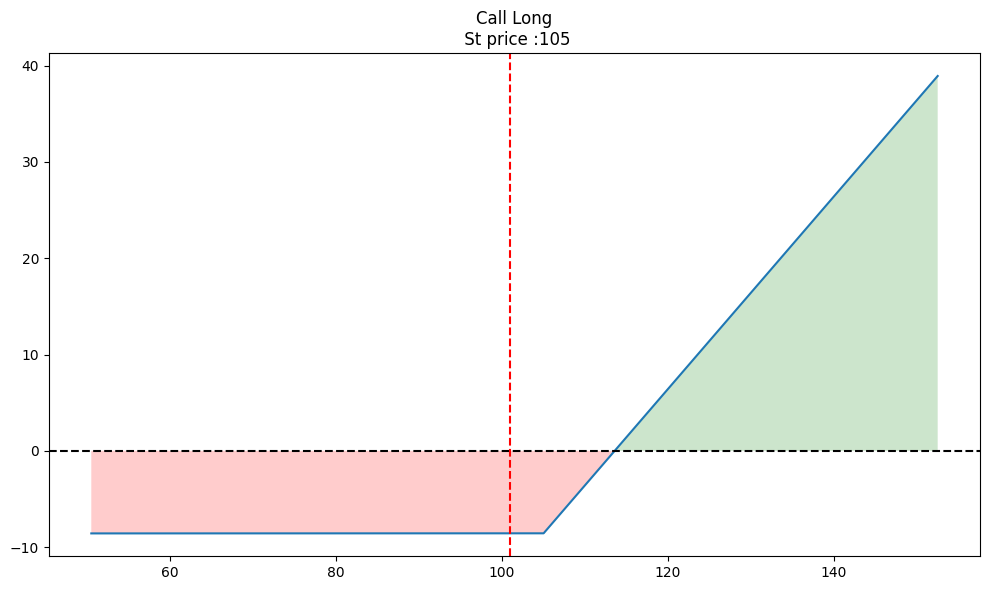

In [41]:
# Plot long call option payoff
op.single_plotter(
    op_type='c',
    spot=optionA.spot,
    spot_range=50,
    strike=optionA.strike,
    tr_type='b',
    op_pr=optionA.callPrice
)

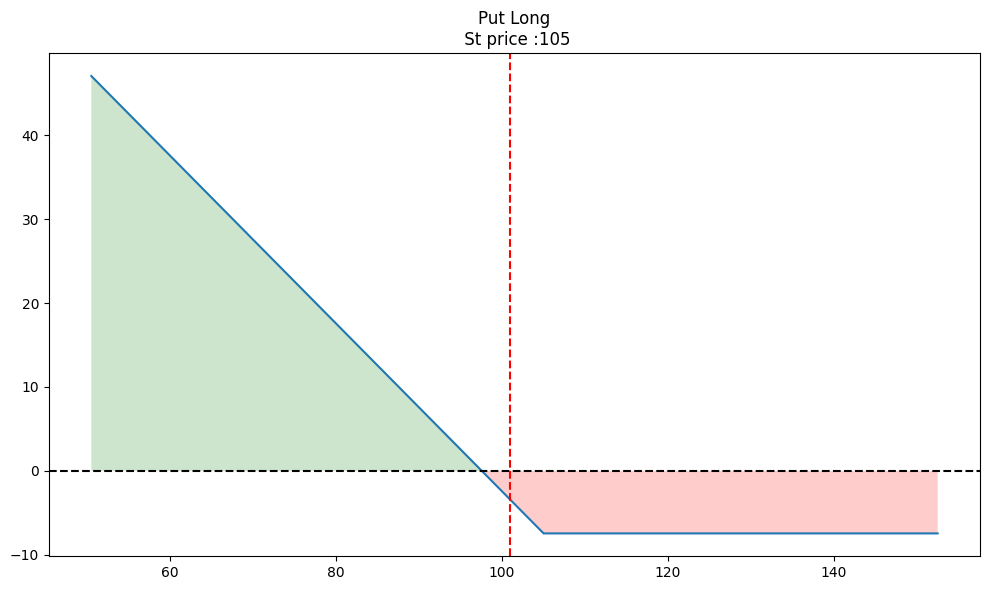

In [42]:
# Plot long put option payoff
op.single_plotter(
    op_type='p',
    spot=optionA.spot,
    spot_range=50,
    strike=optionA.strike,
    tr_type='b',
    op_pr=optionA.putPrice
)

In [43]:
# Short Straddle
op_1 = {'op_type': 'c', 'strike':optionA.strike, 'tr_type': 's', 'op_pr': optionA.callPrice}
op_2 = {'op_type': 'p', 'strike':optionA.strike, 'tr_type': 's', 'op_pr': optionA.putPrice}

# long Straddle
op_3 = {'op_type': 'c', 'strike':optionA.strike, 'tr_type': 'b', 'op_pr': optionA.callPrice}
op_4 = {'op_type': 'p', 'strike':optionA.strike, 'tr_type': 'b', 'op_pr': optionA.putPrice}

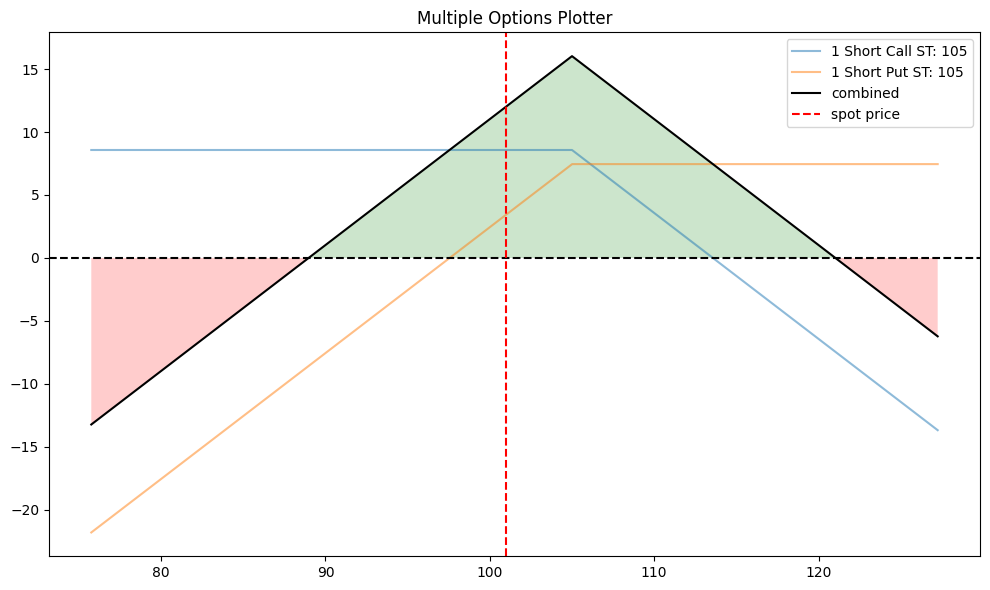

In [44]:
# short straddle plot
op_list = [op_1, op_2]
op.multi_plotter(spot=optionA.spot, spot_range=25, op_list=op_list)

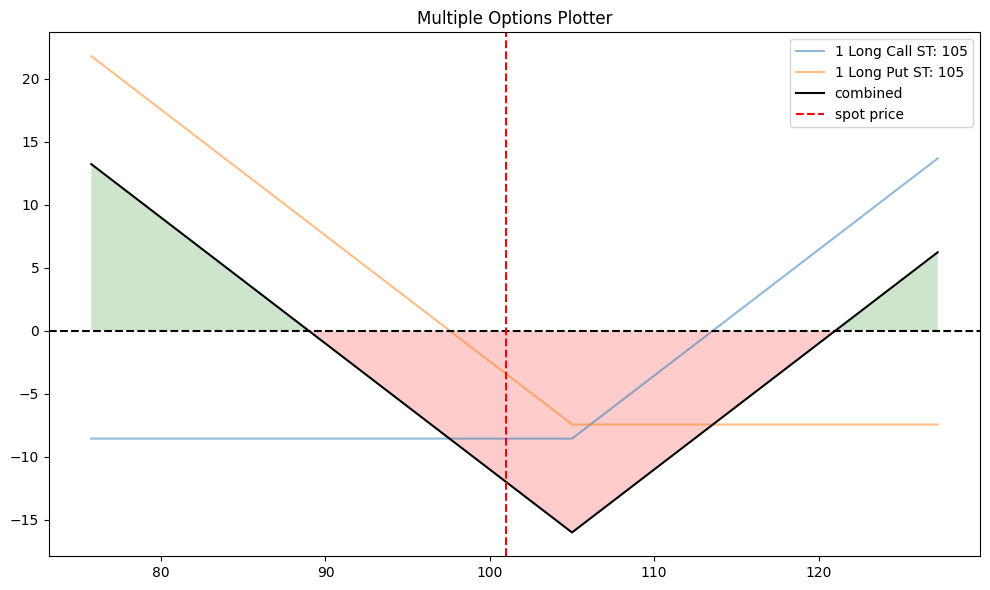

In [45]:
# long straddle plot
op_list2 = [op_3, op_4]
op.multi_plotter(spot=optionA.spot, spot_range=25, op_list=op_list2)

In [46]:
# Strangle
leg1 = BS(100,110,0.05,1,0.2)
leg2 = BS(100,90,0.05,1,0.2)

op_5 = {'op_type': 'c', 'strike':leg1.strike, 'tr_type': 's', 'op_pr': leg1.callPrice}
op_6 = {'op_type': 'p', 'strike':leg2.strike, 'tr_type': 's', 'op_pr': leg2.putPrice}

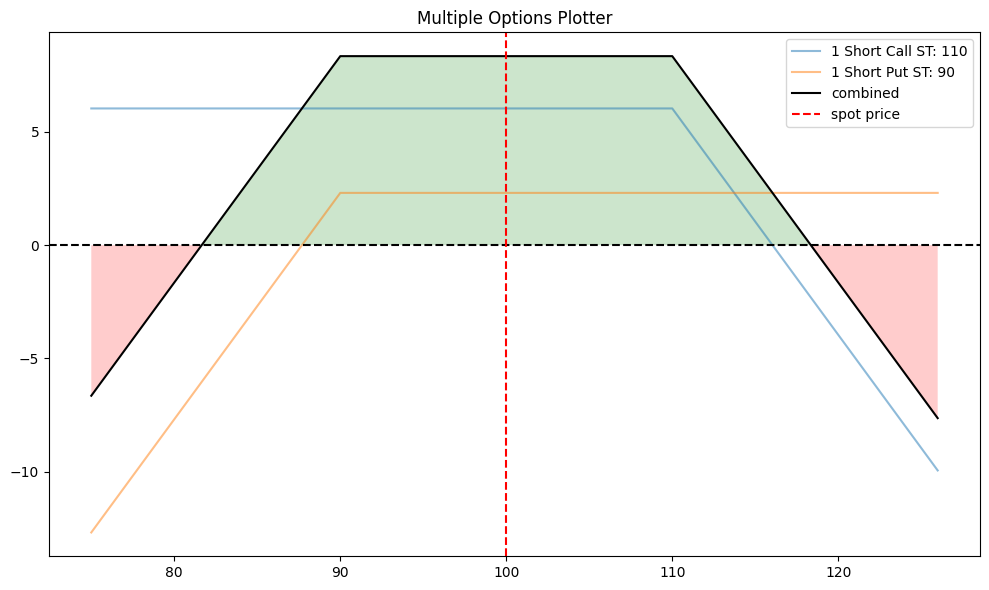

In [47]:
# plot
op_list3 = [op_5, op_6]
op.multi_plotter(spot=leg1.spot, spot_range=25, op_list=op_list3)

In [48]:
# Ironfly
leg1 = BS(100,100,0.05,1,0.2)
leg2 = BS(100,90,0.05,1,0.2)
leg3 = BS(100,110,0.05,1,0.2)

op_1 = {'op_type': 'c', 'strike':leg1.strike, 'tr_type': 's', 'op_pr': leg1.callPrice}
op_2 = {'op_type': 'p', 'strike':leg1.strike, 'tr_type': 's', 'op_pr': leg1.putPrice}
op_3 = {'op_type': 'p', 'strike':leg2.strike, 'tr_type': 'b', 'op_pr': leg2.putPrice}
op_4 = {'op_type': 'c', 'strike':leg3.strike, 'tr_type': 'b', 'op_pr': leg3.callPrice}

In [49]:
#Net cash positions on the ironfly/iron condor
leg1.callPrice + leg1.putPrice - leg2.putPrice - leg3.callPrice

np.float64(7.673924851238031)

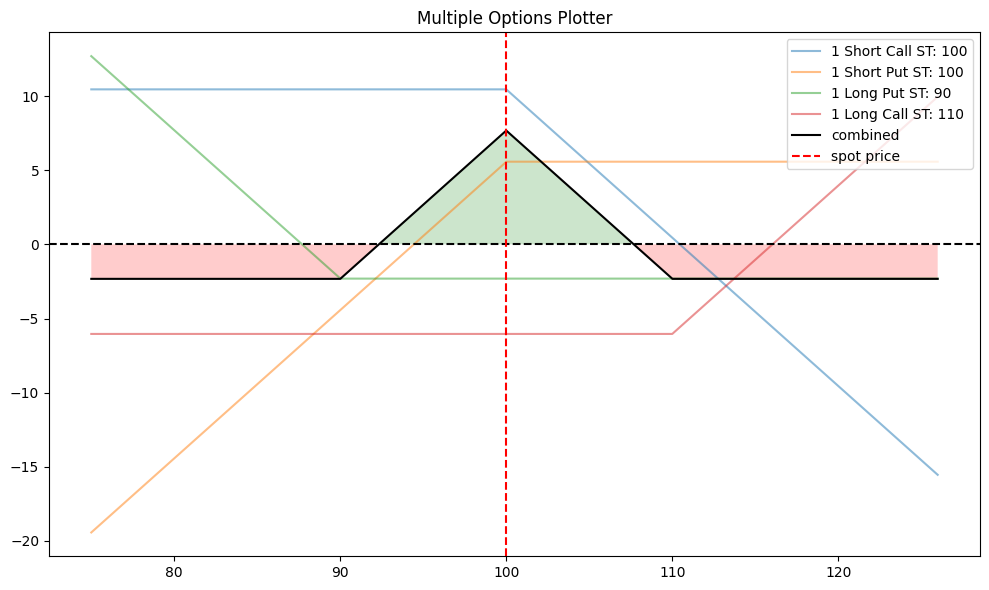

In [50]:
op_list = [op_1, op_2, op_3, op_4]
op.multi_plotter(spot=100, spot_range=25, op_list=op_list)


## SPY Option<a href="#SPY-Option" class="anchor-link"></a>

Retrieve SPY option price from Yahoo Finance using `yfinance` library and manipulate the dataframe using the above Black Scholes option pricing model that we created.
<https://finance.yahoo.com/quote/SPY/options?date=1711584000>

In [125]:
def add_workday_offset(base_date, days_to_add):
    future_date = base_date + timedelta(days=days_to_add)
    # If Saturday, add 2 days to get to Monday
    if future_date.weekday() == 5:
        future_date += timedelta(days=2)
    # If Sunday, add 1 day to get to Monday
    elif future_date.weekday() == 6:
        future_date += timedelta(days=1)
    return future_date

In [132]:
getdate = datetime.today()
future_date = add_workday_offset(getdate, 29)
future_date_str = future_date.strftime("%Y-%m-%d")
future_date_str

'2025-08-15'

In [133]:
# Get SPY option chain
spy = yf.Ticker('SPY')
options = spy.option_chain(future_date_str)

In [134]:
dte = (future_date - datetime.today()).days/365
dte

0.07671232876712329

In [135]:
current_price = yf.Ticker("SPY").info.get("regularMarketPreviousClose")
print(current_price)

624.22


In [142]:
# Price option base on current price as strike 
spy_spot = current_price; spy_strike = current_price; rate = 0.055; dte = dte; vol = 0.20 #0.1248

spy_opt = BS(spy_spot,spy_strike,rate,dte,vol)
print(f'Option Price of SPY with BS Model is {spy_opt.callPrice:0.4f}')

Option Price of SPY with BS Model is 15.1178


In [143]:
# Verify the options output
options.calls.head(5)

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency
0,SPY250815C00245000,2025-06-10 14:06:39+00:00,245.0,356.16,0.00,0.00,0.0,0.0,1,0,0.00001,True,REGULAR,USD
1,SPY250815C00250000,2025-07-15 13:47:44+00:00,250.0,376.98,376.54,379.43,0.0,0.0,1,11,1.19141,True,REGULAR,USD
2,SPY250815C00260000,2025-02-06 17:40:21+00:00,260.0,349.72,317.11,320.27,0.0,0.0,1,4,0.00001,True,REGULAR,USD
3,SPY250815C00265000,2025-04-24 20:01:47+00:00,265.0,287.00,313.97,316.08,0.0,0.0,10,12,0.00001,True,REGULAR,USD
4,SPY250815C00270000,2025-04-07 13:36:57+00:00,270.0,221.25,294.67,297.97,0.0,0.0,1,10,0.00001,True,REGULAR,USD


In [144]:
# Filter calls for strike at or above 600 and less than 750
df = options.calls[(options.calls['strike']>=600) & (options.calls['strike']<=750)]
df.reset_index(drop=True, inplace=True)

# Dataframe manipulation with selected fields
df = pd.DataFrame({'Strike': df['strike'], 
                    'Price': df['lastPrice'], 
                    'ImpVol': df['impliedVolatility']})

# Derive greeks and assign to dataframe as columns
df['Delta'] = df['Gamma'] = df['Vega'] = df['Theta'] = 0.

#Price the options
for i in range(len(df)):
    opt = BS(spy_spot,df['Strike'].iloc[i],rate,dte,df['ImpVol'].iloc[i])
    
    df['Delta'].iloc[i] = opt.callDelta
    df['Gamma'].iloc[i] = opt.gamma
    df['Vega'].iloc[i] = opt.vega
    df['Theta'].iloc[i] = opt.callTheta

# Check output
df.head(5)

,Strike,Price,ImpVol,Delta,Gamma,Vega,Theta
0,600.0,32.47,0.209420,0.783481,0.008103,0.507233,-0.258657
1,601.0,29.90,0.205513,0.778922,0.008357,0.513352,-0.257080
2,602.0,30.26,0.203255,0.772449,0.008589,0.521832,-0.257611
3,603.0,28.77,0.201302,0.765428,0.008821,0.530759,-0.258467
4,604.0,27.00,0.199410,0.758102,0.009056,0.539776,-0.259323


### Visualize Data<a href="#Visualize-Data" class="anchor-link"></a>

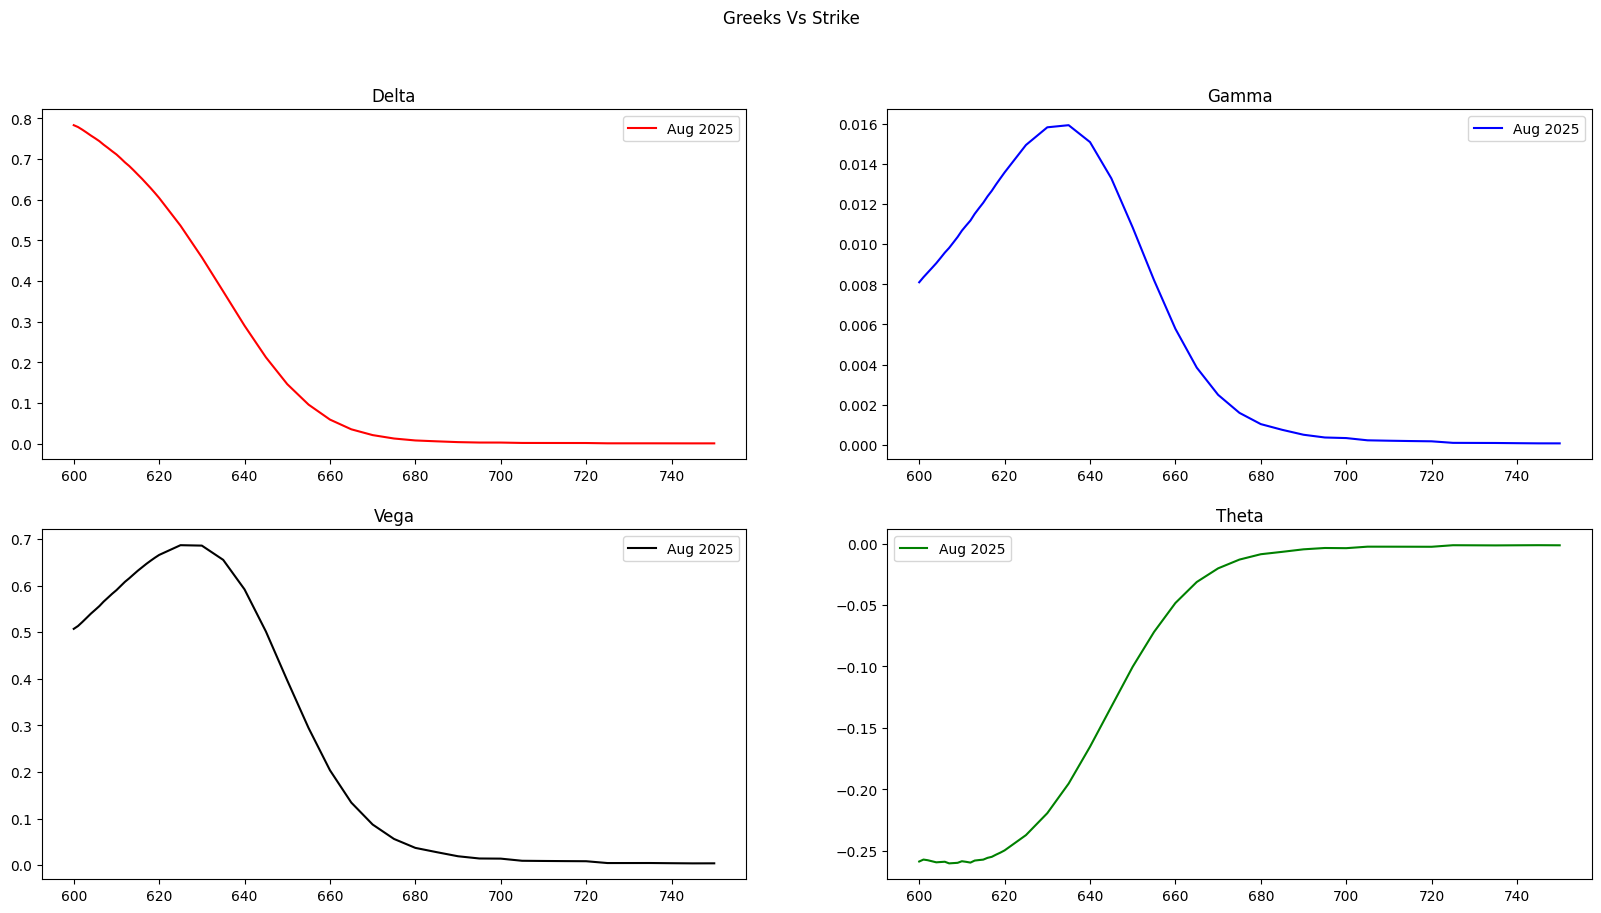

In [145]:
# Plot graph iteratively
fig, ax = plt.subplots(2,2, figsize=(20,10))
label = future_date.strftime("%b %Y")

ax[0,0].plot(df['Strike'], df['Delta'], color='r', label=label)
ax[0,1].plot(df['Strike'], df['Gamma'], color='b', label=label)
ax[1,0].plot(df['Strike'], df['Vega'],  color='k', label=label)
ax[1,1].plot(df['Strike'], df['Theta'], color='g', label=label)
    
# Set axis title
ax[0,0].set_title('Delta'), ax[0,1].set_title('Gamma'), ax[1,0].set_title('Vega'), ax[1,1].set_title('Theta')

# Define legend
ax[0,0].legend(), ax[0,1].legend(), ax[1,0].legend(), ax[1,1].legend()

# Set title
fig.suptitle('Greeks Vs Strike')

plt.show()

In [147]:
# spy straddle
spy_options = BS(spy_spot,spy_strike,0.055,0.022,0.1326)

spy_op_1 = {'op_type': 'c', 'strike':spy_options.strike, 'tr_type': 's', 'op_pr': spy_options.callPrice}
spy_op_2 = {'op_type': 'p', 'strike':spy_options.strike, 'tr_type': 's', 'op_pr': spy_options.putPrice}

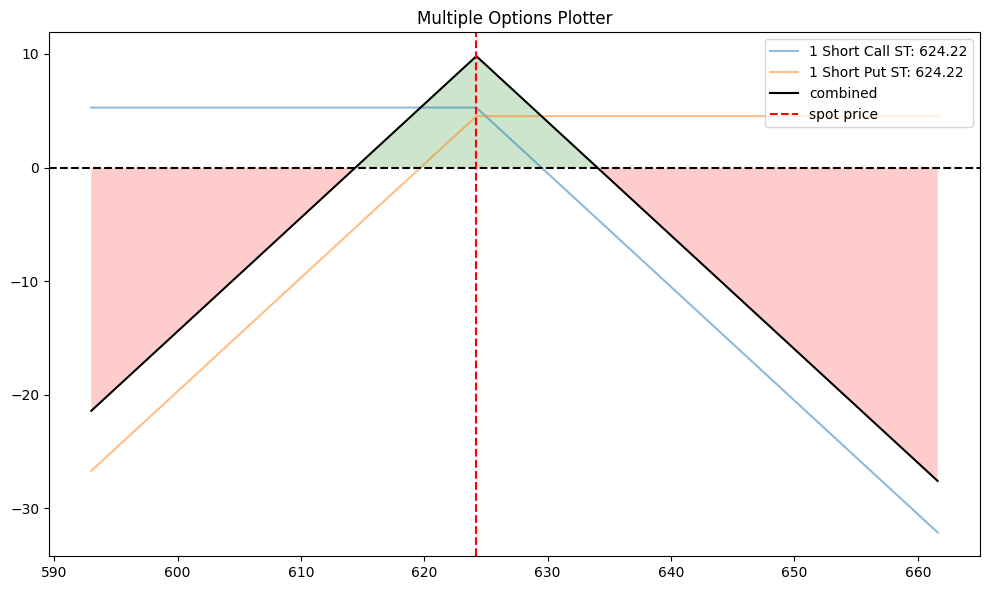

In [148]:
# plot spy straddle
op_list = [spy_op_1, spy_op_2]
op.multi_plotter(spot=spy_options.spot, spot_range=5, op_list=op_list)

In [149]:
# spy straddle
spy_options_leg1 = BS(515,520,0.555,0.022,0.1456)
spy_options_leg2 = BS(515,510,0.0025,0.022,0.124168)

op_7 = {'op_type': 'c', 'strike':spy_options_leg1.strike, 'tr_type': 's', 'op_pr': spy_options_leg1.callPrice}
op_8 = {'op_type': 'p', 'strike':spy_options_leg2.strike, 'tr_type': 's', 'op_pr': spy_options_leg2.putPrice}

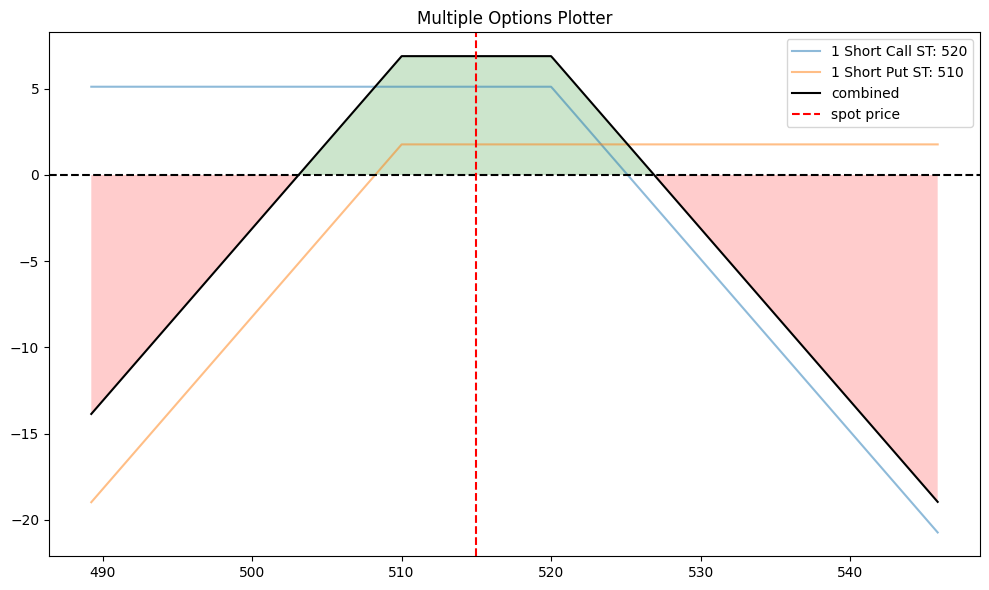

In [150]:
# plot spy straddle
op_list = [op_7, op_8]
op.multi_plotter(spot=spy_options_leg1.spot, spot_range=5, op_list=op_list)

In [151]:
#Greeks for the Straddle
spy_options.callDelta + spy_options.putDelta

np.float64(0.05688548345874467)

In [152]:
spot_range = np.linspace(500,550)
sdelta = []
sgamma = []
svega = []
stheta = []
for i in spot_range:
    opt2 = BS(i,515,rate,dte,.1326)
    sdelta.append(opt2.callDelta+opt2.putDelta)
    sgamma.append(opt2.gamma)
    svega.append(opt2.vega)
    stheta.append(opt2.callTheta + opt2.putTheta)

df2 = pd.DataFrame(
    {'spySpots': spot_range,
     'spy515Delta': sdelta,
     'spy515FGamma': sgamma,
     'spy515Vega': svega,
     'spy515Theta': stheta,
    })
df2

,spySpots,spy515Delta,spy515FGamma,spy515Vega,spy515Theta
0,500.000000,-0.498160,0.017339,0.440930,-0.168531
1,501.020408,-0.462162,0.017933,0.457907,-0.179286
2,502.040816,-0.424989,0.018490,0.474042,-0.189737
3,503.061224,-0.386722,0.019004,0.489213,-0.199819
4,504.081633,-0.347452,0.019472,0.503300,-0.209470
5,505.102041,-0.307278,0.019891,0.516195,-0.218631
6,506.122449,-0.266303,0.020256,0.527794,-0.227246
7,507.142857,-0.224640,0.020565,0.538009,-0.235264
8,508.163265,-0.182405,0.020815,0.546758,-0.242638
9,509.183673,-0.139721,0.021005,0.553974,-0.249327


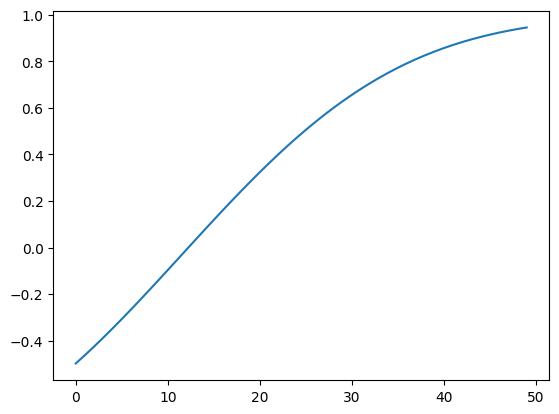

In [153]:
plt.plot(sdelta);

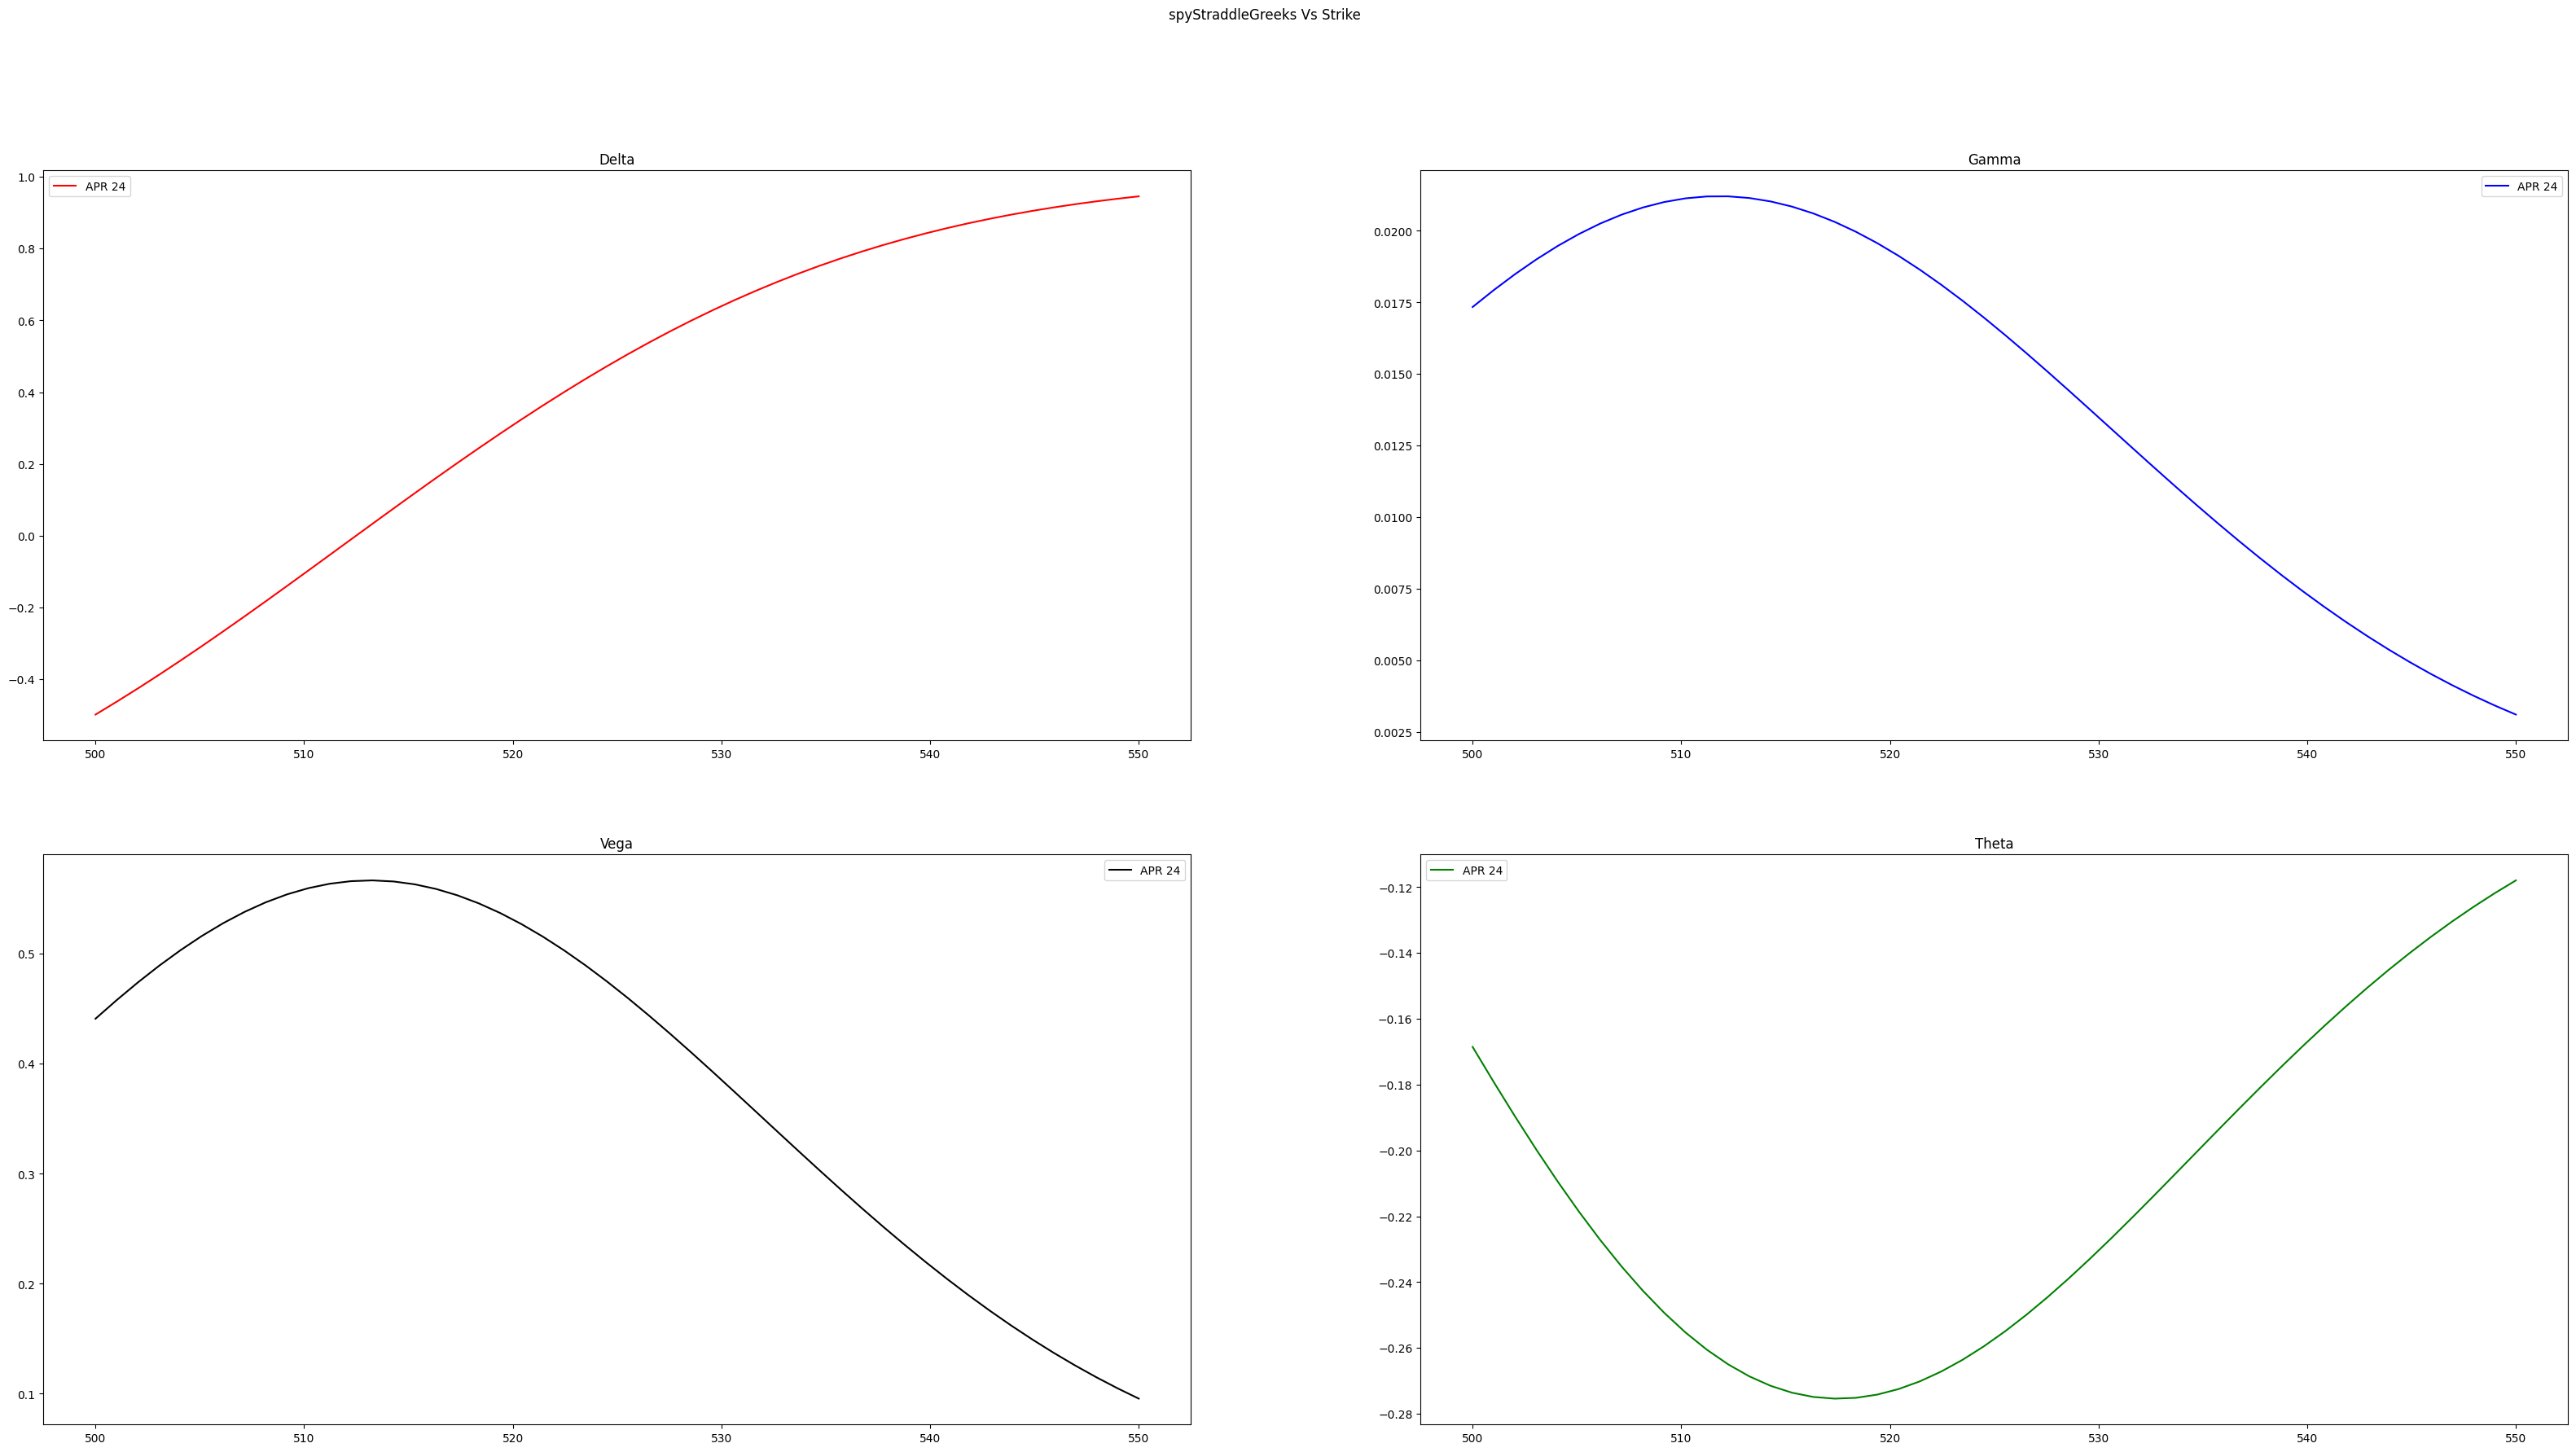

In [154]:
# Plot graph iteratively
fig2, ax = plt.subplots(2,2, figsize=(40,20))

ax[0,0].plot(df2['spySpots'], df2['spy515Delta'], color='r', label='APR 24')
ax[0,1].plot(df2['spySpots'], df2['spy515FGamma'], color='b', label='APR 24')
ax[1,0].plot(df2['spySpots'], df2['spy515Vega'],  color='k', label='APR 24')
ax[1,1].plot(df2['spySpots'], df2['spy515Theta'], color='g', label='APR 24')
    
# Set axis title
ax[0,0].set_title('Delta'), ax[0,1].set_title('Gamma'), ax[1,0].set_title('Vega'), ax[1,1].set_title('Theta')

# Define legend
ax[0,0].legend(), ax[0,1].legend(), ax[1,0].legend(), ax[1,1].legend()

# Set title
fig2.suptitle('spyStraddleGreeks Vs Strike')

plt.show()

In [155]:
#YT Val of demonstration of Delta Hedging

In [156]:
quP = [10, 10.56, 7.99, 9.66, 13.16]
ttm = np.linspace(1,0,5)
quPDeltas = []
quPPrice = []
CFs = []
for i in range(len(quP)):
    stck = BS(quP[i],10,0.05,ttm[i],.4)
    quPDeltas.append(round(stck.callDelta,3))
    quPPrice.append(round(stck.callPrice,3))

for j in range(len(quPPrice)):
    CFs.append(round(quPPrice[j]*np.exp((0.05*ttm[j])),3))
print(quPDeltas)
print(quPPrice)
print(CFs)

[np.float64(0.627), np.float64(0.67), np.float64(0.287), np.float64(0.496), 1.0]
[np.float64(1.802), np.float64(1.9), np.float64(0.352), np.float64(0.675), np.float64(3.16)]
[np.float64(1.894), np.float64(1.973), np.float64(0.361), np.float64(0.683), np.float64(3.16)]


In [157]:
ttl = np.linspace(1,0,5)
ttl

array([1.  , 0.75, 0.5 , 0.25, 0.  ])

In [158]:
np.random.seed()
ranNum = (np.random.standard_normal(10))
pricePa = [10]
for i in range(4):
    S = pricePa[i] * (1+ 0.05*ttm[i+1] + .4 * np.sqrt(ttm[i+1])*ranNum[i])
    pricePa.append(S)
pricePa

[10,
 np.float64(2.783559614998452),
 np.float64(3.233338804904105),
 np.float64(3.2448146059044025),
 np.float64(3.2448146059044025)]